# Netflix Prize - EDA

Exploring the dataset before building the recommendation models.

**Workflow:**
- load the ratings + movie titles
- check rating distribution, user activity & movie popularity
- check sparsity and how ratings change over time
- save a cleaned dataset for the modeling notebook

Choosing the subset:
- the full dataset has ~100M ratings in 4 files
- I am using combined_data_1.txt fully (~24M ratings, movies 1-4499) because of RAM limits

In [12]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For plots
sns.set_theme(style="whitegrid")

# Dataset info
data_dir = "../data"

# Given in the PS: rating >= 3.5 means relevant
relevance_cutoff = 3.5   

# Filters for the modeling dataset (explained at the end)
min_user_ratings  = 10
min_movie_ratings = 30
n_sample_users    = 50_000

seed = 42
np.random.seed(seed)

## 1. Loading the ratings:

- The file is not a normal csv
- I observed that every movie block starts with a line like `1:` and then
the ratings come as `user,rating,date` lines

**FIXED the older slow version:**
- My first version looped over every line but that was too slow for 24M rows, so I am
using the (read_csv + ffill) approach that is common in Kaggle notebooks
- For this dataset:
1. read everything as a 3 column csv, the `1:` lines get NaN rating
2. use that to fill the movie id downwards, then drop those header lines
3. keeping the date column this time - needed for the time based train/test split later

In [ ]:
# Loading the ratings
def load_ratings_file(filepath, nrows=None):
    raw_df = pd.read_csv(filepath, header=None,
                         names=["user_id","rating","date"],
                         dtype={"user_id": str}, nrows=nrows)

    # Using the new approach
    is_movie_row = raw_df["rating"].isna()

    # Filling the movie id down to its rating rows
    raw_df["movie_id"] = (raw_df["user_id"].where(is_movie_row)
                          .str.replace(":", "", regex=False)
                          .astype("float").ffill().astype("int32"))

    df = raw_df[~is_movie_row].copy()
    
    # Using smaller dtypes for RAM efficiency
    df["user_id"] = df["user_id"].astype("int32")
    df["rating"]  = df["rating"].astype("int8")
    df["date"]    = pd.to_datetime(df["date"])
    return df[["user_id", "movie_id", "rating", "date"]].reset_index(drop=True)

ratings_df = load_ratings_file(f"{data_dir}/combined_data_1.txt")

print("Ratings:",len(ratings_df))
print("Users:",ratings_df["user_id"].nunique())
print("Movies:",ratings_df["movie_id"].nunique())
print("Dates:",ratings_df["date"].min().date(),"to",ratings_df["date"].max().date())

Ratings: 24053764
Users: 470758
Movies: 4499
Dates: 1999-11-11 to 2005-12-31


## 2. Loading movie titles:

- Observed that movie_titles.csv is latin-1 encoded and some titles have commas inside them
- So, I decided to split them only on the first 2 commas, which resulted in showing that some years are NULL

In [14]:
# Loading movie titles
def get_movie_titles(path):
    rows = []
    with open(path,"r",encoding="latin1") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            movie_id, year, title = line.split(",",2)
            rows.append((int(movie_id), int(year) if year != "NULL" else np.nan, title))
    return pd.DataFrame(rows, columns=["movie_id","year","title"])

movie_titles = get_movie_titles(f"{data_dir}/movie_titles.csv")
print(len(movie_titles),"movies loaded")
movie_titles.head()

17770 movies loaded


,movie_id,year,title
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW


## 3. Rating distribution:

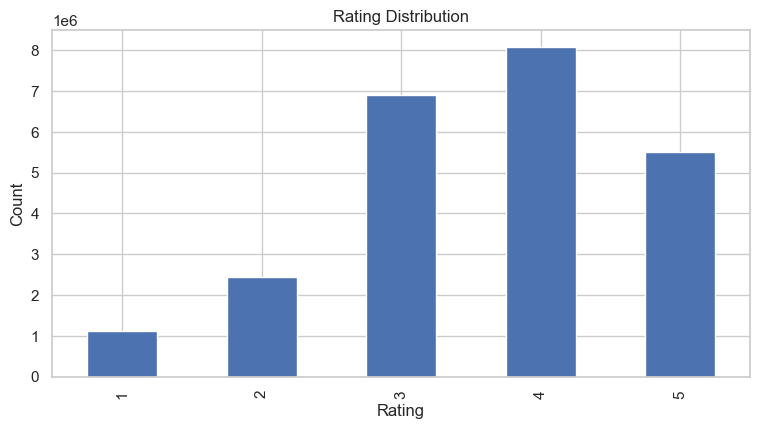

Share of ratings >= 3.5 (relevant as per PS): 56.5%
Mean rating: 3.6


In [15]:
# Checking rating distribution
ratings_df["rating"].value_counts().sort_index().plot(kind="bar")

# Plotting it
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# Checking with our relevant cutoff
share_relevant = (ratings_df["rating"] >= relevance_cutoff).mean()
print(f"Share of ratings >= {relevance_cutoff} (relevant as per PS): {share_relevant:.1%}")
print("Mean rating:",round(ratings_df["rating"].mean(),3))

**Observations:**
- ratings lean towards 4 and 5, people mostly rate movies they chose to watch
- a big share of ratings already counts as "relevant" (>= 3.5), this is important for MAP@10 later as if we only rank a user's own test movies, almost everything is relevant and the score becomes meaninglessly high
- so, in the modeling, I computed MAP by ranking the full catalog
- since the mean rating 3.6, a model that just predicts averages will already look decent on RMSE, so I will compare against a baseline model

## 4. User activity:

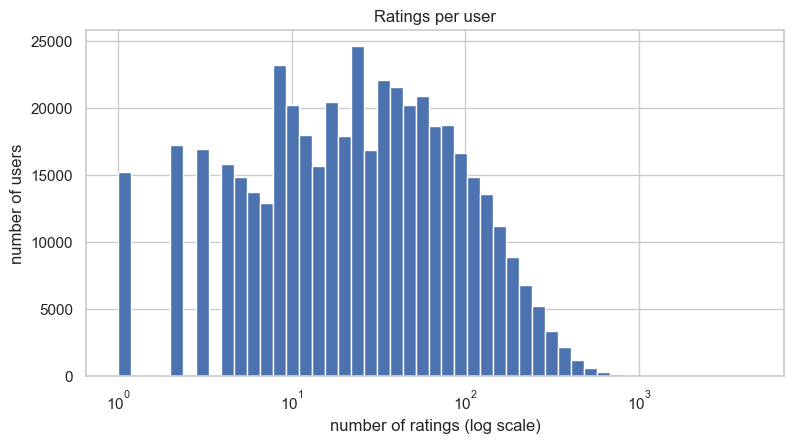

count    470758.0
mean         51.1
std          74.4
min           1.0
25%           8.0
50%          24.0
75%          64.0
max        4467.0
dtype: float64


In [17]:
# Checking the activity of user
user_activity = ratings_df.groupby("user_id").size()

# Plotting it using 'histogram'
user_activity.plot(kind="hist", bins=np.logspace(0,np.log10(user_activity.max()),50))
plt.xscale("log")
plt.title("Ratings per user")
plt.xlabel("number of ratings (log scale)")
plt.ylabel("number of users")
plt.show()

print(user_activity.describe().round(1))

**Observations:**
- it shows very long tail: most users have rated only few movies and in contrast a small group of power users has hundreds/thousands of ratings
- this is basically what we called 'the cold start problem' - for the majority of users, the model has very little signal to work with
- because of this I kept only users with at least 10 ratings for modeling that we will see later, so the time based split leaves at least 2 ratings in test per user 

This makes the metrics a bit optimistic compared to all users

## 5. Movie popularity:

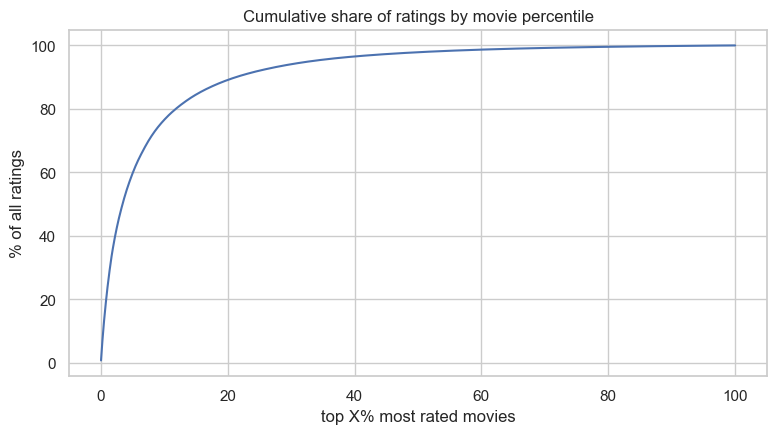

In [20]:
# Checking the movie popularity with the help of ratings
movie_stats = ratings_df.groupby("movie_id").agg(
    n_ratings=("rating","size"),
    avg_rating=("rating","mean"))

# Share of ratings in POPULAR movies (Using %ile)
shares = movie_stats["n_ratings"].sort_values(ascending=False).cumsum()/movie_stats["n_ratings"].sum()
plt.plot(np.arange(1,len(shares) + 1)/len(shares)*100,shares.values*100)
plt.title("Cumulative share of ratings by movie percentile")
plt.xlabel("top X% most rated movies")
plt.ylabel("% of all ratings")
plt.show()

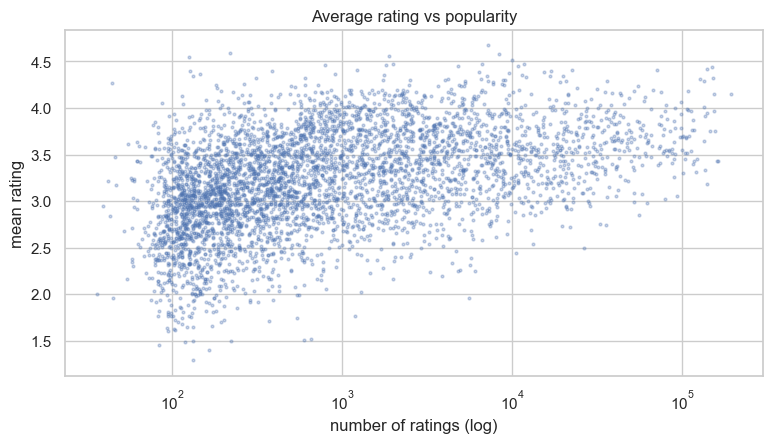

In [21]:
# Plotting average rating vs popularity
plt.scatter(movie_stats["n_ratings"],movie_stats["avg_rating"],s=4,alpha=0.3)
plt.xscale("log")
plt.title("Average rating vs popularity")
plt.xlabel("number of ratings (log)")
plt.ylabel("mean rating")
plt.show()

In [22]:
# Top 10 most rated movies
top_movies = (movie_stats.sort_values("n_ratings", ascending=False).head(10)
              .merge(movie_titles, on="movie_id"))
top_movies[["title","year","n_ratings","avg_rating"]].round(2)

,title,year,n_ratings,avg_rating
0,Pirates of the Caribbean: The Curse of the Bla...,2003.0,193941,4.15
1,What Women Want,2000.0,162597,3.43
2,Bruce Almighty,2003.0,160454,3.43
3,The Italian Job,2003.0,156183,3.76
4,American Beauty,1999.0,154832,3.96
5,Shrek 2,2004.0,153996,4.14
6,The Sixth Sense,1999.0,151292,4.33
7,Lord of the Rings: The Fellowship of the Ring,2001.0,149866,4.43
8,50 First Dates,2004.0,145519,3.75
9,Finding Nemo (Widescreen),2003.0,140979,4.42


**Observations:**
- ratings are concentrated on a small head of popular movies, the rest is a long tail
- the scatter plot is funnel shaped: movies with very few ratings can have extreme averages
- KEY INSIGHT: a movie rated (4.8 by 40 fans) is not actually better than one rated (4.2 by 100k people)
- this looks like a trap for the models - a rating prediction model might put these tiny sample high mean movies on top of recommendation lists  

LATER, I checked this in the modeling notebook

## 6. Ratings over time:

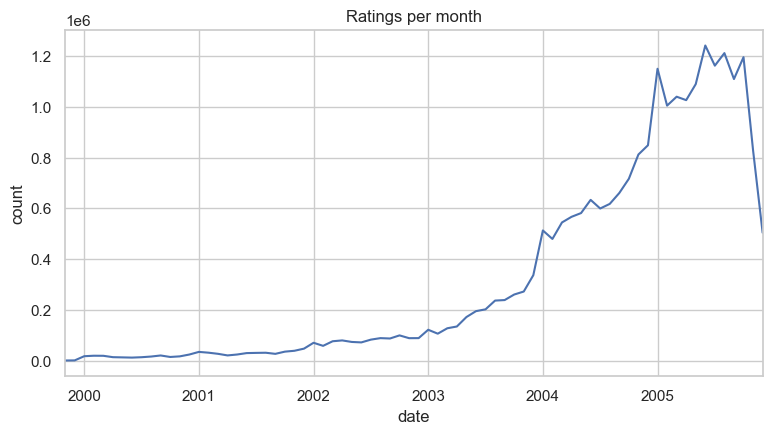

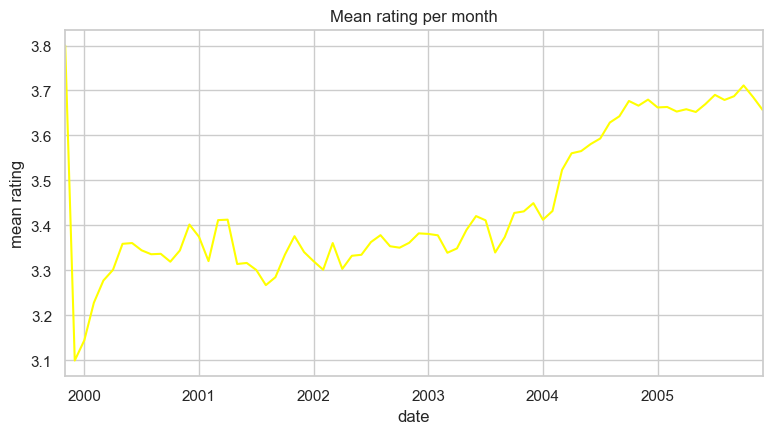

In [23]:
# How time is affecting ratings
monthly = ratings_df.set_index("date").resample("ME").agg(
    volume=("rating","size"),
    mean_rating=("rating","mean"))

# Plotting the analysis for volume
monthly["volume"].plot(title="Ratings per month")
plt.ylabel("count")
plt.show()

# Plotting the analysis for mean rating
monthly["mean_rating"].plot(title="Mean rating per month",color="yellow")
plt.ylabel("mean rating")
plt.show()

**Observations:**
- volume grows a lot over the years
- but the mean rating wanders & jump ups around 2004 
- so, as a result the data is not stable over time, a RANDOM train/test split would mix past and future ratings of the same user, which can't happen in reality

That's why keeping this in mind, I used a time based split in the modeling notebook: oldest 80% of each user's ratings for training, newest 20% for test

## 7. Checking Sparsity:

In [25]:
# USERS & MOVIES
n_users = ratings_df["user_id"].nunique()
n_movies = ratings_df["movie_id"].nunique()

# Checking sparsity
sparsity = 1 - len(ratings_df)/(n_users * n_movies)
print(f"Matrix size: {n_users:,} users x {n_movies:,} movies")
print(f"Sparsity:{sparsity:.2%}")

Matrix size: 470,758 users x 4,499 movies
Sparsity:98.86%


**Observations:**

98.86% of the user-movie matrix is empty

- This is a very important info as:
1. The models have to generalize from very few observed cells - which is the main argument for matrix factorization (SVD), which
compresses users and movies into small latent vectors
2. It also rules out user-based KNN here: a user x user similarity matrix for 470k users would never fit in memory, so I use item-based KNN instead of user-based CF

## 8. Do users rate on different scales?

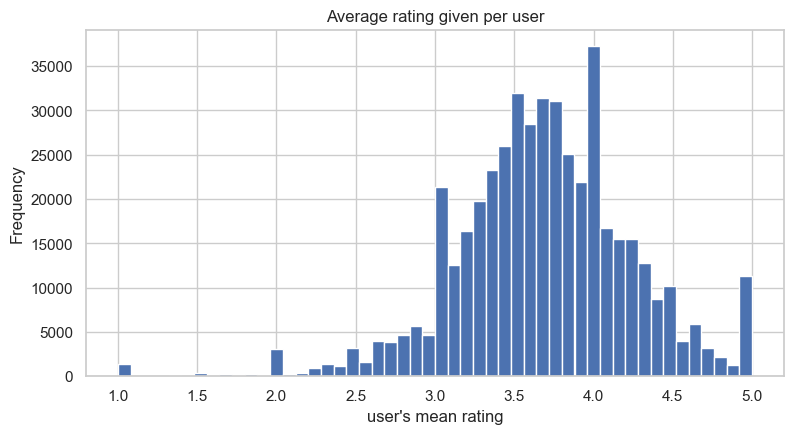

count    470758.00
mean          3.68
std           0.56
min           1.00
25%           3.35
50%           3.68
75%           4.00
max           5.00
Name: rating, dtype: float64


In [28]:
# Checking the avg rating per user
user_avg_rating = ratings_df.groupby("user_id")["rating"].mean()

# Plotting it as 'histogram'
user_avg_rating.plot(kind="hist",bins=50)
plt.title("Average rating given per user")
plt.xlabel("user's mean rating")
plt.show()
print(user_avg_rating.describe().round(2))

**Observations:**

Yes - some users average above 4, some below 3

- A "4" from a aggressive rater means more than a "4" from a normal one
 
So the models should consider user bias: that's why I used KNNWithMeans instead of plain KNNBasic and SVD with bias terms

## 9. Saving the modeling dataset:

Filters applied (reasons given above):
- movies with at least 30 ratings (rare movies have uncertain stats)
- users with at least 10 ratings (need history for the time split)
- random sample of 50k users so KNN stays computable on my machine

In [ ]:
# Saving the dataset using groupby transform
df = ratings_df.copy()

df = df[df.groupby("movie_id")["rating"].transform("size") >= min_movie_ratings]
df = df[df.groupby("user_id")["rating"].transform("size") >= min_user_ratings]

if df["user_id"].nunique() > n_sample_users:
    keep = pd.Series(df["user_id"].unique()).sample(n_sample_users,random_state=seed)
    df = df[df["user_id"].isin(set(keep))]

print("Modeling dataset:", len(df),"ratings,",
      df["user_id"].nunique(),"users,",df["movie_id"].nunique(),"movies")

df.to_parquet(f"{data_dir}/ratings_model.parquet",index=False)
print("saved")

Modeling dataset: 3438319 ratings, 50000 users, 4499 movies
saved
